In [118]:
"""
Fetch last 1 year of daily OHLCV candlestick data for multiple symbols (e.g. BTCUSDT, ETHUSDT).
Tries multiple Binance mirror endpoints to handle geo-restrictions (HTTP 451).
Falls back to CoinGecko if all Binance mirrors fail.
No API key required.
"""

import requests
import pandas as pd
from datetime import datetime, timedelta, timezone


# ── API endpoints to try in order ─────────────────────────────────────────────
ENDPOINTS = [
    "https://api1.binance.com/api/v3/klines",
    "https://api2.binance.com/api/v3/klines",
    "https://api3.binance.com/api/v3/klines",
    "https://api4.binance.com/api/v3/klines",
    "https://data-api.binance.vision/api/v3/klines",
]


def fetch_klines_from_url(url, symbol, interval, start_ms, end_ms):
    """Fetch klines from a specific URL with pagination."""
    all_klines = []
    current_start = start_ms

    while current_start < end_ms:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_start,
            "endTime": end_ms,
            "limit": 1000,
        }
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()

        if not data:
            break

        all_klines.extend(data)
        last_open_time = data[-1][0]
        current_start = last_open_time + 1

        if len(data) < 1000:
            break

    return all_klines


def fetch_binance_klines(symbol, interval, start_ms, end_ms):
    """Try each Binance mirror endpoint in order until one works."""
    for url in ENDPOINTS:
        try:
            print(f"  Trying: {url}")
            data = fetch_klines_from_url(url, symbol, interval, start_ms, end_ms)
            print(f"  Success!")
            return data
        except requests.HTTPError as e:
            print(f"  Failed ({e.response.status_code}), trying next...")
        except requests.ConnectionError:
            print(f"  Connection error, trying next...")

    raise RuntimeError(
        "All Binance endpoints failed (likely geo-restricted).\n"
        "Switching to CoinGecko fallback..."
    )


def fetch_coingecko_fallback(coin_id="bitcoin", days=365):
    """
    Fallback: fetch daily OHLCV from CoinGecko (free, no API key needed).
    coin_id examples: 'bitcoin', 'ethereum'
    - OHLC  : /coins/{coin_id}/ohlc          (4-hourly for 365d, resampled to daily)
    - Volume: /coins/{coin_id}/market_chart  (daily volume in USD)
    Both are merged into a single DataFrame.
    """
    print(f"\n  Trying CoinGecko fallback for '{coin_id}' (free, no API key)...")

    # ── 1. Fetch OHLC ──────────────────────────────────────────────────────
    ohlc_url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/ohlc"
    ohlc_resp = requests.get(ohlc_url, params={"vs_currency": "usd", "days": days}, timeout=15)
    ohlc_resp.raise_for_status()

    df_ohlc = pd.DataFrame(ohlc_resp.json(), columns=["timestamp", "open", "high", "low", "close"])
    df_ohlc["open_time"] = pd.to_datetime(df_ohlc["timestamp"], unit="ms", utc=True)
    df_ohlc.set_index("open_time", inplace=True)
    df_ohlc.drop(columns=["timestamp"], inplace=True)
    df_ohlc = df_ohlc.astype(float)

    # Resample 4-hourly → daily
    df_ohlc = df_ohlc.resample("1D").agg(
        {"open": "first", "high": "max", "low": "min", "close": "last"}
    ).dropna()

    # ── 2. Fetch Volume (USD) via market_chart ─────────────────────────────
    chart_url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    chart_resp = requests.get(
        chart_url,
        params={"vs_currency": "usd", "days": days, "interval": "daily"},
        timeout=15
    )
    chart_resp.raise_for_status()
    chart_data = chart_resp.json()

    df_vol = pd.DataFrame(chart_data["total_volumes"], columns=["timestamp", "volume_usd"])
    df_vol["open_time"] = pd.to_datetime(df_vol["timestamp"], unit="ms", utc=True)
    df_vol.set_index("open_time", inplace=True)
    df_vol.drop(columns=["timestamp"], inplace=True)
    df_vol["volume_usd"] = df_vol["volume_usd"].astype(float)
    df_vol = df_vol.resample("1D").sum()

    # ── 3. Merge OHLC + Volume ─────────────────────────────────────────────
    df = df_ohlc.join(df_vol, how="left")
    df["volume_coin"] = df["volume_usd"] / df["close"]

    print(f"  CoinGecko OHLCV data fetched successfully for '{coin_id}'!")
    return df


def klines_to_dataframe(klines):
    """Convert raw Binance kline list to a clean Pandas DataFrame."""
    columns = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "num_trades",
        "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
    ]
    df = pd.DataFrame(klines, columns=columns)

    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms", utc=True)

    float_cols = ["open", "high", "low", "close", "volume",
                  "quote_asset_volume", "taker_buy_base_volume", "taker_buy_quote_volume"]
    df[float_cols] = df[float_cols].astype(float)
    df["num_trades"] = df["num_trades"].astype(int)

    # Rename for clarity: volume = coin volume, quote_asset_volume = USDT volume
    df.rename(columns={"volume": "volume_coin", "quote_asset_volume": "volume_usd"}, inplace=True)

    df = df[["open_time", "open", "high", "low", "close",
             "volume_coin", "volume_usd", "num_trades", "close_time"]]
    df.set_index("open_time", inplace=True)
    return df


def print_summary(df, symbol=""):
    label = f" [{symbol}]" if symbol else ""
    print(f"\n--- First 5 rows{label} ---")
    print(df.head())
    print(f"\n--- Last 5 rows{label} ---")
    print(df.tail())
    print(f"\nShape: {df.shape}")
    print(f"\n--- Price Summary{label} ---")
    print(f"  Highest Close  : ${df['close'].max():,.2f}")
    print(f"  Lowest  Close  : ${df['close'].min():,.2f}")
    print(f"  Latest  Close  : ${df['close'].iloc[-1]:,.2f}")
    vol_col = "volume_coin" if "volume_coin" in df.columns else "volume_btc"
    if vol_col in df.columns:
        print(f"  Avg Daily Vol  : {df[vol_col].mean():,.2f} {symbol.replace('USDT','')}")
    if "volume_usd" in df.columns:
        print(f"  Avg Daily Vol  : ${df['volume_usd'].mean():,.0f} USD")


def fetch_symbol(symbol, interval, start_ms, end_ms):
    """Fetch OHLCV data for a single symbol, with CoinGecko fallback."""
    # Maps Binance symbol → CoinGecko coin_id
    coingecko_ids = {
        "BTCUSDT": "bitcoin",
        "ETHUSDT": "ethereum",
    }

    try:
        klines = fetch_binance_klines(symbol, interval, start_ms, end_ms)
        print(f"  Total candles fetched: {len(klines)}")
        return klines_to_dataframe(klines), "binance"
    except RuntimeError as e:
        print(f"\n{e}")
        coin_id = coingecko_ids.get(symbol, symbol.replace("USDT", "").lower())
        df = fetch_coingecko_fallback(coin_id=coin_id, days=365)
        return df, "coingecko"


def main():
    symbols  = ["BTCUSDT", "ETHUSDT"]   # ← Add more symbols here if needed
    interval = "1d"

    now          = datetime.now(timezone.utc)
    one_year_ago = now - timedelta(days=365)
    start_ms     = int(one_year_ago.timestamp() * 1000)
    end_ms       = int(now.timestamp() * 1000)

    results = {}

    for symbol in symbols:
        print(f"\n{'='*55}")
        print(f"  Fetching {symbol} daily data: {one_year_ago.date()} → {now.date()}")
        print(f"{'='*55}")

        df, source = fetch_symbol(symbol, interval, start_ms, end_ms)
        print_summary(df, symbol)

        csv_filename = f"{symbol}_daily_1year{'_coingecko' if source == 'coingecko' else ''}.csv"
        df.to_csv(csv_filename)
        print(f"\n  Data saved to '{csv_filename}'")

        results[symbol] = df

    print(f"\n{'='*55}")
    print(f"  Done! Fetched data for: {', '.join(results.keys())}")
    print(f"{'='*55}\n")

    return results


if __name__ == "__main__":
    data = main()
    df_btc = data["BTCUSDT"]
    df_eth = data["ETHUSDT"]


  Fetching BTCUSDT daily data: 2025-03-23 → 2026-03-23
  Trying: https://api1.binance.com/api/v3/klines
  Success!
  Total candles fetched: 365

--- First 5 rows [BTCUSDT] ---
                               open      high       low     close  \
open_time                                                           
2025-03-24 00:00:00+00:00  86082.50  88765.43  85519.09  87498.16   
2025-03-25 00:00:00+00:00  87498.16  88539.63  86310.00  87392.87   
2025-03-26 00:00:00+00:00  87392.88  88275.00  85860.00  86909.17   
2025-03-27 00:00:00+00:00  86909.17  87756.39  85800.00  87232.01   
2025-03-28 00:00:00+00:00  87232.01  87515.67  83585.00  84424.38   

                           volume_coin    volume_usd  num_trades  \
open_time                                                          
2025-03-24 00:00:00+00:00  30115.62111  2.636766e+09     2916713   
2025-03-25 00:00:00+00:00  22643.25248  1.979572e+09     2802815   
2025-03-26 00:00:00+00:00  18408.78485  1.606407e+09     2380154   

In [119]:
df = pd.read_csv("BTCUSDT_daily_1year.csv")
df

,open_time,open,high,low,close,volume_coin,volume_usd,num_trades,close_time
0,2025-03-24 00:00:00+00:00,86082.50,88765.43,85519.09,87498.16,30115.62111,2.636766e+09,2916713,2025-03-24 23:59:59.999000+00:00
1,2025-03-25 00:00:00+00:00,87498.16,88539.63,86310.00,87392.87,22643.25248,1.979572e+09,2802815,2025-03-25 23:59:59.999000+00:00
2,2025-03-26 00:00:00+00:00,87392.88,88275.00,85860.00,86909.17,18408.78485,1.606407e+09,2380154,2025-03-26 23:59:59.999000+00:00
3,2025-03-27 00:00:00+00:00,86909.17,87756.39,85800.00,87232.01,17098.03897,1.487969e+09,2376381,2025-03-27 23:59:59.999000+00:00
4,2025-03-28 00:00:00+00:00,87232.01,87515.67,83585.00,84424.38,27182.73169,2.309947e+09,3236085,2025-03-28 23:59:59.999000+00:00
...,...,...,...,...,...,...,...,...,...
360,2026-03-19 00:00:00+00:00,71246.55,71613.79,68793.35,69930.00,22364.81819,1.566574e+09,4972526,2026-03-19 23:59:59.999000+00:00
361,2026-03-20 00:00:00+00:00,69930.01,71367.00,69388.00,70510.73,18121.16745,1.273813e+09,4369971,2026-03-20 23:59:59.999000+00:00
362,2026-03-21 00:00:00+00:00,70510.73,71100.94,68571.42,68918.12,13397.16750,9.426939e+08,1640086,2026-03-21 23:59:59.999000+00:00
363,2026-03-22 00:00:00+00:00,68918.12,69588.79,67360.66,67859.00,14843.78682,1.018926e+09,3269152,2026-03-22 23:59:59.999000+00:00


In [120]:
pip install mplfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [121]:
df.head()

,open_time,open,high,low,close,volume_coin,volume_usd,num_trades,close_time
0,2025-03-24 00:00:00+00:00,86082.50,88765.43,85519.09,87498.16,30115.62111,2.636766e+09,2916713,2025-03-24 23:59:59.999000+00:00
1,2025-03-25 00:00:00+00:00,87498.16,88539.63,86310.00,87392.87,22643.25248,1.979572e+09,2802815,2025-03-25 23:59:59.999000+00:00
2,2025-03-26 00:00:00+00:00,87392.88,88275.00,85860.00,86909.17,18408.78485,1.606407e+09,2380154,2025-03-26 23:59:59.999000+00:00
3,2025-03-27 00:00:00+00:00,86909.17,87756.39,85800.00,87232.01,17098.03897,1.487969e+09,2376381,2025-03-27 23:59:59.999000+00:00
4,2025-03-28 00:00:00+00:00,87232.01,87515.67,83585.00,84424.38,27182.73169,2.309947e+09,3236085,2025-03-28 23:59:59.999000+00:00


In [122]:
df.dtypes

open_time          str
open           float64
high           float64
low            float64
close          float64
volume_coin    float64
volume_usd     float64
num_trades       int64
close_time         str
dtype: object

In [123]:
# Handling null values

df.isnull().sum()

open_time      0
open           0
high           0
low            0
close          0
volume_coin    0
volume_usd     0
num_trades     0
close_time     0
dtype: int64

In [124]:
# Handling duplicate values

df.duplicated().sum()

np.int64(0)

In [125]:
df.shape

(365, 9)

In [126]:
numeric_columns = ["open", "high", "low", "close", "volume_coin", "volume_usd", "num_trades"]

In [127]:
# Converting these columns into float
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, axis=1)

In [128]:
df.dtypes

open_time          str
open           float64
high           float64
low            float64
close          float64
volume_coin    float64
volume_usd     float64
num_trades     float64
close_time         str
dtype: object

In [129]:
df.describe()

,open,high,low,close,volume_coin,volume_usd,num_trades
count,365.000000,365.000000,365.000000,365.000000,365.000000,3.650000e+02,3.650000e+02
mean,97893.959534,99383.210658,96234.247507,97845.904849,19750.604792,1.877578e+09,3.837291e+06
std,16007.897579,15961.699991,16095.980379,16069.653124,12209.315889,1.043378e+09,2.205664e+06
min,62909.870000,65026.750000,60000.000000,62909.860000,3104.117220,2.813214e+08,6.533050e+05
25%,87369.560000,88765.430000,85860.000000,87369.560000,12203.135360,1.174001e+09,2.214249e+06
50%,102312.950000,104192.700000,100300.950000,102312.940000,17573.092940,1.698896e+09,3.291182e+06
75%,111004.900000,112575.270000,109394.810000,111004.890000,23706.497990,2.348873e+09,5.010211e+06
max,124658.540000,126199.630000,123084.000000,124658.540000,106298.828990,7.349751e+09,1.536401e+07


In [130]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   open_time    365 non-null    str    
 1   open         365 non-null    float64
 2   high         365 non-null    float64
 3   low          365 non-null    float64
 4   close        365 non-null    float64
 5   volume_coin  365 non-null    float64
 6   volume_usd   365 non-null    float64
 7   num_trades   365 non-null    float64
 8   close_time   365 non-null    str    
dtypes: float64(7), str(2)
memory usage: 25.8 KB


In [131]:
df['open_time'] = pd.to_datetime(df['open_time'])
df['open_time'] = df['open_time'].dt.strftime('%Y-%m-%d')

df['close_time'] = pd.to_datetime(df['close_time'])
df['close_time'] = df['close_time'].dt.strftime('%Y-%m-%d')

In [132]:
df

,open_time,open,high,low,close,volume_coin,volume_usd,num_trades,close_time
0,2025-03-24,86082.50,88765.43,85519.09,87498.16,30115.62111,2.636766e+09,2916713.0,2025-03-24
1,2025-03-25,87498.16,88539.63,86310.00,87392.87,22643.25248,1.979572e+09,2802815.0,2025-03-25
2,2025-03-26,87392.88,88275.00,85860.00,86909.17,18408.78485,1.606407e+09,2380154.0,2025-03-26
3,2025-03-27,86909.17,87756.39,85800.00,87232.01,17098.03897,1.487969e+09,2376381.0,2025-03-27
4,2025-03-28,87232.01,87515.67,83585.00,84424.38,27182.73169,2.309947e+09,3236085.0,2025-03-28
...,...,...,...,...,...,...,...,...,...
360,2026-03-19,71246.55,71613.79,68793.35,69930.00,22364.81819,1.566574e+09,4972526.0,2026-03-19
361,2026-03-20,69930.01,71367.00,69388.00,70510.73,18121.16745,1.273813e+09,4369971.0,2026-03-20
362,2026-03-21,70510.73,71100.94,68571.42,68918.12,13397.16750,9.426939e+08,1640086.0,2026-03-21
363,2026-03-22,68918.12,69588.79,67360.66,67859.00,14843.78682,1.018926e+09,3269152.0,2026-03-22


In [133]:
df.rename(columns={'volume_coin': 'volume'}, inplace=True)

In [134]:
df

,open_time,open,high,low,close,volume,volume_usd,num_trades,close_time
0,2025-03-24,86082.50,88765.43,85519.09,87498.16,30115.62111,2.636766e+09,2916713.0,2025-03-24
1,2025-03-25,87498.16,88539.63,86310.00,87392.87,22643.25248,1.979572e+09,2802815.0,2025-03-25
2,2025-03-26,87392.88,88275.00,85860.00,86909.17,18408.78485,1.606407e+09,2380154.0,2025-03-26
3,2025-03-27,86909.17,87756.39,85800.00,87232.01,17098.03897,1.487969e+09,2376381.0,2025-03-27
4,2025-03-28,87232.01,87515.67,83585.00,84424.38,27182.73169,2.309947e+09,3236085.0,2025-03-28
...,...,...,...,...,...,...,...,...,...
360,2026-03-19,71246.55,71613.79,68793.35,69930.00,22364.81819,1.566574e+09,4972526.0,2026-03-19
361,2026-03-20,69930.01,71367.00,69388.00,70510.73,18121.16745,1.273813e+09,4369971.0,2026-03-20
362,2026-03-21,70510.73,71100.94,68571.42,68918.12,13397.16750,9.426939e+08,1640086.0,2026-03-21
363,2026-03-22,68918.12,69588.79,67360.66,67859.00,14843.78682,1.018926e+09,3269152.0,2026-03-22


In [135]:
# Adding Percentage Change from last close price
df['Daily Return %'] = (df['close'].pct_change() * 100).round(2)
df

,open_time,open,high,low,close,volume,volume_usd,num_trades,close_time,Daily Return %
0,2025-03-24,86082.50,88765.43,85519.09,87498.16,30115.62111,2.636766e+09,2916713.0,2025-03-24,NaN
1,2025-03-25,87498.16,88539.63,86310.00,87392.87,22643.25248,1.979572e+09,2802815.0,2025-03-25,-0.12
2,2025-03-26,87392.88,88275.00,85860.00,86909.17,18408.78485,1.606407e+09,2380154.0,2025-03-26,-0.55
3,2025-03-27,86909.17,87756.39,85800.00,87232.01,17098.03897,1.487969e+09,2376381.0,2025-03-27,0.37
4,2025-03-28,87232.01,87515.67,83585.00,84424.38,27182.73169,2.309947e+09,3236085.0,2025-03-28,-3.22
...,...,...,...,...,...,...,...,...,...,...
360,2026-03-19,71246.55,71613.79,68793.35,69930.00,22364.81819,1.566574e+09,4972526.0,2026-03-19,-1.85
361,2026-03-20,69930.01,71367.00,69388.00,70510.73,18121.16745,1.273813e+09,4369971.0,2026-03-20,0.83
362,2026-03-21,70510.73,71100.94,68571.42,68918.12,13397.16750,9.426939e+08,1640086.0,2026-03-21,-2.26
363,2026-03-22,68918.12,69588.79,67360.66,67859.00,14843.78682,1.018926e+09,3269152.0,2026-03-22,-1.54


In [136]:
# Moving Averages

df = df.sort_values(by='open_time')

In [137]:
# 10-period Moving Average
df['MA_10'] = df['close'].rolling(window=10).mean()

# 20-period Moving Average
df['MA_20'] = df['close'].rolling(window=20).mean()

In [138]:
df[['close', 'MA_10', 'MA_20']].head(25)

,close,MA_10,MA_20
0,87498.16,NaN,NaN
1,87392.87,NaN,NaN
2,86909.17,NaN,NaN
3,87232.01,NaN,NaN
4,84424.38,NaN,NaN
5,82648.54,NaN,NaN
6,82389.99,NaN,NaN
7,82550.01,NaN,NaN
8,85158.34,NaN,NaN
9,82516.29,84871.976,NaN


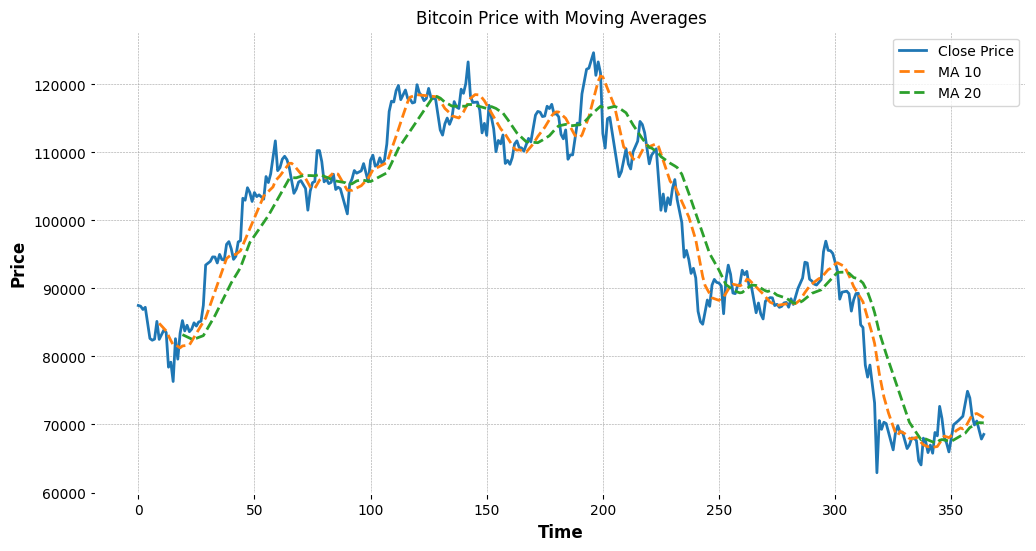

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df['close'], label='Close Price')
plt.plot(df['MA_10'], label='MA 10', linestyle='--')
plt.plot(df['MA_20'], label='MA 20', linestyle='--')

plt.title("Bitcoin Price with Moving Averages")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()

plt.show()

In [140]:
df.columns

Index(['open_time', 'open', 'high', 'low', 'close', 'volume', 'volume_usd',
       'num_trades', 'close_time', 'Daily Return %', 'MA_10', 'MA_20'],
      dtype='str')

In [141]:
# Finding Outliers

import pandas as pd

df_clean = df.copy()

# Rename columns for safety
df_clean.columns = df_clean.columns.str.replace(' ', '_')
df_clean.columns = df_clean.columns.str.replace('%', 'pct')

cols = ['open', 'high', 'low', 'close', 'volume', 
        'volume_usd', 'num_trades', 'Daily_Return_pct']

bounds = {}

for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    bounds[col] = (lower, upper)

    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

open: 0 outliers
high: 0 outliers
low: 0 outliers
close: 0 outliers
volume: 13 outliers
volume_usd: 11 outliers
num_trades: 8 outliers
Daily_Return_pct: 17 outliers


In [142]:
# Removing OUtliers

for col in cols:
    lower, upper = bounds[col]
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print("Final shape after removing outliers:", df_clean.shape)

Final shape after removing outliers: (339, 12)


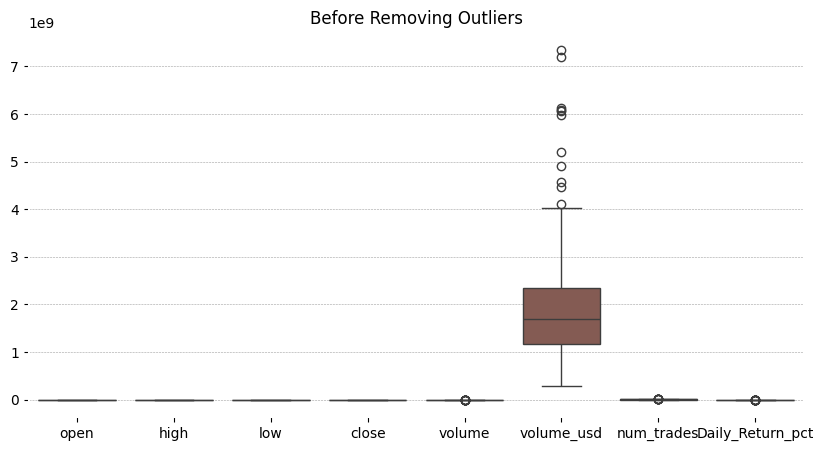

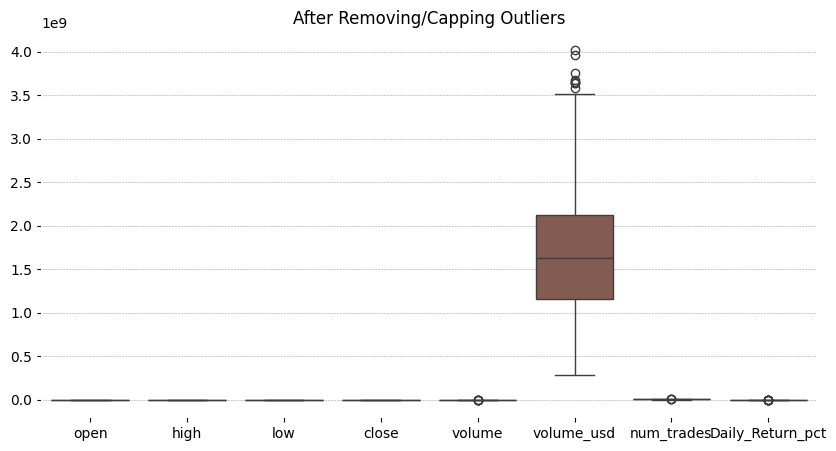

In [143]:
# Visualizing 

import seaborn as sns
import matplotlib.pyplot as plt

# Rename both (best practice)
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('%', 'pct')

df_clean.columns = df_clean.columns.str.replace(' ', '_')
df_clean.columns = df_clean.columns.str.replace('%', 'pct')

cols = ['open', 'high', 'low', 'close', 'volume', 
        'volume_usd', 'num_trades', 'Daily_Return_pct']

# Before
plt.figure(figsize=(10,5))
sns.boxplot(data=df[cols])
plt.title("Before Removing Outliers")
plt.show()

# After
plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean[cols])
plt.title("After Removing/Capping Outliers")
plt.show()

In [145]:
# Volatility Index

# Return-based (better for ML)
df['Return'] = df['close'].pct_change()
df['Volatility_20'] = df['Return'].rolling(20).std() * 100

# Price range-based (good for quick insight)
df['Volatility_Index'] = (df['high'] - df['low']) / df['close'] * 100

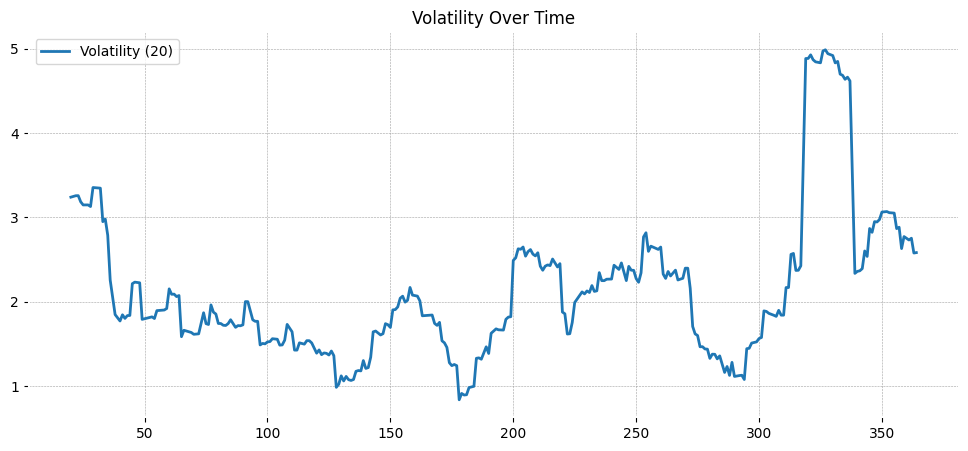

In [146]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Volatility_20'], label='Volatility (20)')
plt.title("Volatility Over Time")
plt.legend()
plt.show()

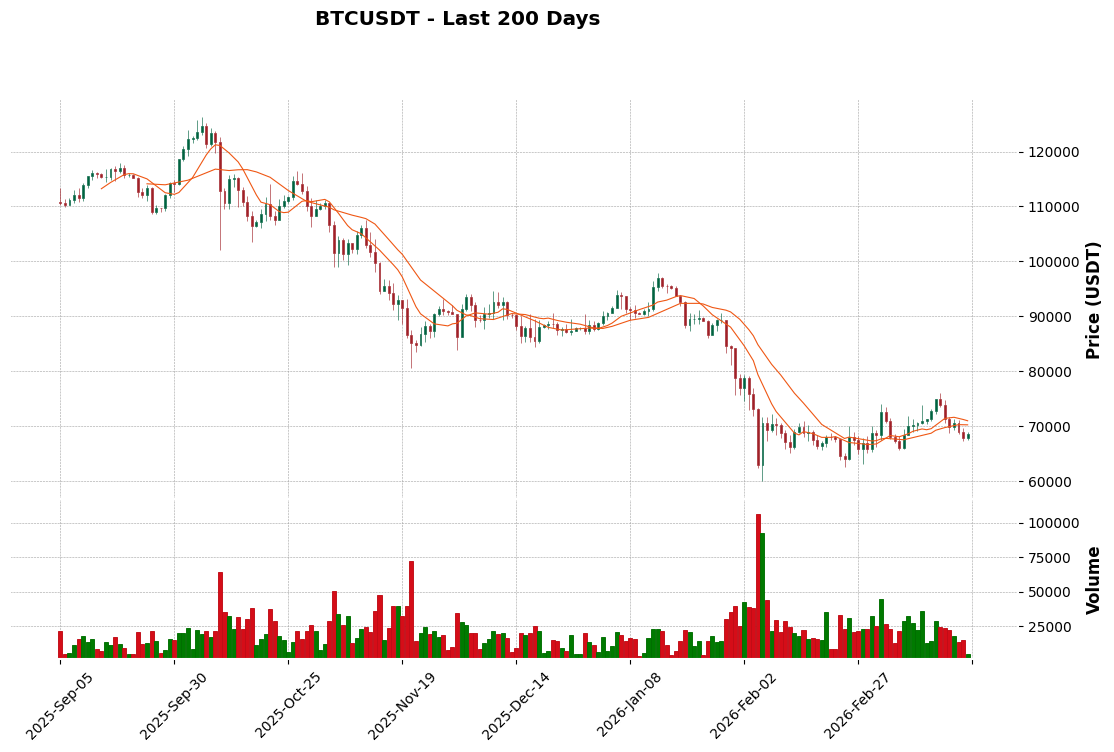

In [144]:
import mplfinance as mpf
import pandas as pd

# Step 1: Convert open_time to datetime and set as index
df['open_time'] = pd.to_datetime(df['open_time'])
df_plot = df.set_index('open_time')

# Step 2: Plot candlestick chart
mpf.plot(
    df_plot.tail(200),
    type='candle',          # candlestick chart
    style='charles',        # clean style (try 'yahoo', 'binance', 'nightclouds')
    volume=True,            # volume bars at bottom
    title='BTCUSDT - Last 200 Days',
    ylabel='Price (USDT)',
    ylabel_lower='Volume',
    figsize=(14, 8),
    mav=(10,20)
)

In [147]:
df

,open_time,open,high,low,close,volume,volume_usd,num_trades,close_time,Daily_Return_pct,MA_10,MA_20,Return,Volatility_20,Volatility_Index
0,2025-03-24,86082.50,88765.43,85519.09,87498.16,30115.62111,2.636766e+09,2916713.0,2025-03-24,NaN,NaN,NaN,NaN,NaN,3.710181
1,2025-03-25,87498.16,88539.63,86310.00,87392.87,22643.25248,1.979572e+09,2802815.0,2025-03-25,-0.12,NaN,NaN,-0.001203,NaN,2.551272
2,2025-03-26,87392.88,88275.00,85860.00,86909.17,18408.78485,1.606407e+09,2380154.0,2025-03-26,-0.55,NaN,NaN,-0.005535,NaN,2.778763
3,2025-03-27,86909.17,87756.39,85800.00,87232.01,17098.03897,1.487969e+09,2376381.0,2025-03-27,0.37,NaN,NaN,0.003715,NaN,2.242743
4,2025-03-28,87232.01,87515.67,83585.00,84424.38,27182.73169,2.309947e+09,3236085.0,2025-03-28,-3.22,NaN,NaN,-0.032186,NaN,4.655847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2026-03-19,71246.55,71613.79,68793.35,69930.00,22364.81819,1.566574e+09,4972526.0,2026-03-19,-1.85,71560.959,69943.2580,-0.018479,2.747162,4.033233
361,2026-03-20,69930.01,71367.00,69388.00,70510.73,18121.16745,1.273813e+09,4369971.0,2026-03-20,0.83,71617.169,70120.1315,0.008304,2.732014,2.806665
362,2026-03-21,70510.73,71100.94,68571.42,68918.12,13397.16750,9.426939e+08,1640086.0,2026-03-21,-2.26,71489.795,70277.2140,-0.022587,2.752870,3.670326
363,2026-03-22,68918.12,69588.79,67360.66,67859.00,14843.78682,1.018926e+09,3269152.0,2026-03-22,-1.54,71221.561,70228.6610,-0.015368,2.577383,3.283470
